In [2]:
import matplotlib


from data_tools import query
from data_tools.collections import TimeSeries
from datetime import datetime, date, time, timezone
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import dill
import os

#each 5 seconds
utc_offset_h = 2
start_utc = time(5 , 00, 00) #querying i svancouver time, influxdb gives utc
stop_utc = time(4, 45, 40)
date_start = date(2025, 6, 30)
date_stop = date(2025, 7, 2)
start_time = datetime.combine(date_start, start_utc, tzinfo=timezone.utc)
stop_time = datetime.combine(date_stop, stop_utc, tzinfo=timezone.utc)

client = query.DBClient()
temp_array_expected_aliter: TimeSeries = client.query_time_series(start_time, stop_time, "MosfetTemperatureA")


In [3]:
#alternate data:

from data_tools import query
from data_tools.collections import TimeSeries
from datetime import datetime, date, time, timezone
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import dill
import os

#each 5 seconds
utc_offset_h = 2
start_utc = time(5 + utc_offset_h , 00, 00) #querying i svancouver time, influxdb gives utc
stop_utc = time(4 +  utc_offset_h, 45, 40)
date_start = date(2025, 7, 1)
date_stop = date(2025, 7, 2)
start_time = datetime.combine(date_start, start_utc, tzinfo=timezone.utc)
stop_time = datetime.combine(date_stop, stop_utc, tzinfo=timezone.utc)

client = query.DBClient()
temp_array_expected_aliter: TimeSeries = client.query_time_series(start_time, stop_time, "MosfetTemperatureA")
speed_kph: TimeSeries = client.query_time_series(start_time, stop_time, "MotorRotatingSpeed")

print(temp_array_expected_aliter)
#this is almost steady state, and expected temperature is roughly 31.8 degrees celsius. note that individual cells do have an upto 5 C difference, which is actually quite a lot.




[27.46449661 27.46548943 27.46648225 ... 27.29558551 27.29614538
 27.29670525]


In [4]:
#save collected data of 15 minutes

import os
import dill

out_dir = os.path.join("../../motor_analysis", "data", "array_temperature_aliter_2025-07-01")
mosfetA_file_aliter = os.path.join(out_dir, "mosfetA_aliter.bin")

os.makedirs(out_dir, exist_ok=True)

for filepath, data in zip([mosfetA_file_aliter],
                          [temp_array_expected_aliter]):
    with open(filepath, 'wb') as f:
        dill.dump(data, f)



#time zone matching conventions??

alternate data: data over the first 4 days of fsgp 2025

In [2]:
from data_tools import query
from data_tools.collections import TimeSeries
from datetime import datetime, date, time, timezone
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import dill
import os

#each 5 seconds
utc_offset_h = 2
start_utc = time(22 , 00, 00) #querying i svancouver time, influxdb gives utc
stop_utc = time(20, 45, 00)
date_start = date(2025, 7, 1)
date_stop = date(2025, 7, 6)
start_time = datetime.combine(date_start, start_utc, tzinfo=timezone.utc)
stop_time = datetime.combine(date_stop, stop_utc, tzinfo=timezone.utc)

client = query.DBClient()
temp_array_fsgp: TimeSeries = client.query_time_series(start_time, stop_time, field=  "MosfetTemperatureA")
speed_kph: TimeSeries = client.query_time_series(start_time, stop_time, "MotorRotatingSpeed")

#print(temp_array_expected_aliter)
#this is almost steady state, and expected temperature is roughly 31.8 degrees celsius. note that individual cells do have an upto 5 C difference, which is actually quite a lot.




ApiException: (401)
Reason: Unauthorized
HTTP response headers: HTTPHeaderDict({'Server': 'nginx/1.27.1', 'Date': 'Sat, 29 Nov 2025 22:07:18 GMT', 'Content-Type': 'application/json; charset=utf-8', 'Content-Length': '55', 'Connection': 'keep-alive', 'X-Influxdb-Build': 'OSS', 'X-Influxdb-Version': 'v2.7.1', 'X-Platform-Error-Code': 'unauthorized'})
HTTP response body: b'{"code":"unauthorized","message":"unauthorized access"}'


In [52]:
type(temp_array_fsgp)

data_tools.collections.time_series.TimeSeries

In [53]:
df_fsgp = pd.DataFrame(temp_array_fsgp)

In [54]:
len(df_fsgp)

2831521

In [55]:
len(hourly_data['shortwave_radiation_instant'])

120

querying from openmeteo to get solar irradiance data

- this is hourly irradiance over 4 days


In [56]:
import openmeteo_requests

import pandas as pd
import requests_cache
from retry_requests import retry

# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after = 3600)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

# Make sure all required weather variables are listed here
# The order of variables in hourly or daily is important to assign them correctly below
url = "https://historical-forecast-api.open-meteo.com/v1/forecast"
params = {
	"latitude": 36.9760,
	"longitude": 86.4491,
	"start_date": "2025-07-02",
	"end_date": "2025-07-06",
	"minutely_15": ["temperature_2m", "wind_speed_10m", "shortwave_radiation_instant"],
}
responses = openmeteo.weather_api(url, params=params)

# Process first location. Add a for-loop for multiple locations or weather models
response = responses[0]
print(f"Coordinates: {response.Latitude()}°N {response.Longitude()}°E")
print(f"Elevation: {response.Elevation()} m asl")
print(f"Timezone difference to GMT+0: {response.UtcOffsetSeconds()}s")

# Process minutely_15 data. The order of variables needs to be the same as requested.
minutely_15 = response.Minutely15()
minutely_15_temperature_2m = minutely_15.Variables(0).ValuesAsNumpy()
minutely_15_shortwave_radiation_instant = minutely_15.Variables(1).ValuesAsNumpy()
minutely_15_wind_speed_10m = minutely_15.Variables(2).ValuesAsNumpy()

minutely_15_data = {"date": pd.date_range(
	start = pd.to_datetime(minutely_15.Time(), unit = "s", utc = True),
	end =  pd.to_datetime(minutely_15.TimeEnd(), unit = "s", utc = True),
	freq = pd.Timedelta(seconds = minutely_15.Interval()),
	inclusive = "left"
)}

minutely_15_data["temperature_2m"] = minutely_15_temperature_2m
minutely_15_data["shortwave_radiation_instant"] = minutely_15_shortwave_radiation_instant
minutely_15_data["wind_speed_10m"] = minutely_15_wind_speed_10m

minutely_15_dataframe = pd.DataFrame(data = minutely_15_data)
print("\nMinutely15 data\n", minutely_15_dataframe)

Coordinates: 37.0°N 86.5°E
Elevation: 5139.0 m asl
Timezone difference to GMT+0: 0s

Minutely15 data
                          date  temperature_2m  shortwave_radiation_instant  \
0   2025-07-02 00:00:00+00:00           -2.20                     5.588703   
1   2025-07-02 00:15:00+00:00           -2.15                     5.351785   
2   2025-07-02 00:30:00+00:00           -2.15                     5.014219   
3   2025-07-02 00:45:00+00:00           -2.05                     4.680000   
4   2025-07-02 01:00:00+00:00           -1.95                     4.680000   
..                        ...             ...                          ...   
475 2025-07-06 22:45:00+00:00           -1.25                    20.240196   
476 2025-07-06 23:00:00+00:00           -1.05                    19.881649   
477 2025-07-06 23:15:00+00:00           -0.95                    19.917469   
478 2025-07-06 23:30:00+00:00           -0.90                    19.959719   
479 2025-07-06 23:45:00+00:00           

minutely open meteo data starts at 2 july, 12am and goes to 6 july 22 45
therefore on influx i query for 1 july 10  pm to 6 july 20 45


utc i s2 hours ahead of vancouver

Plot some relevant data. this will further be used to generate the relevant coefficients

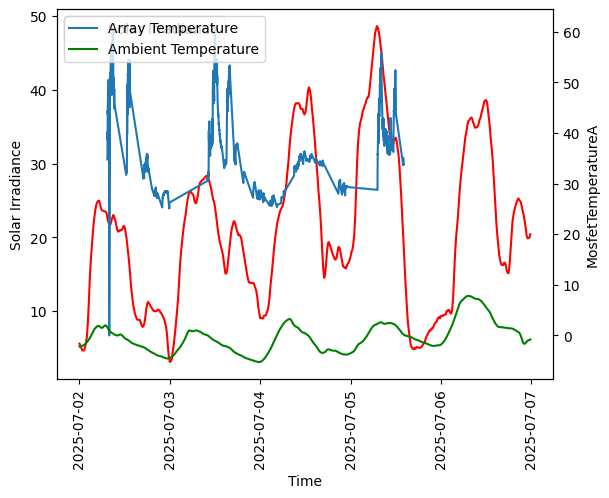

In [64]:
#this graph shows solar irradiance, array temperature, and ambient temperature over July 2-6 (FSGP 2025)

fig, ax1 = plt.subplots()
ax_twin = ax1.twinx()

plt.plot(temp_array_fsgp.datetime_x_axis, temp_array_fsgp, label = "Array Temperature")
plt.plot(minutely_15_data['date'],minutely_15_data['temperature_2m'], color = 'green', label = "Ambient Temperature")
# plt.plot(minutely_15_data['date'], minutely_15_data['wind_speed_10m'], color = 'blue', label = "Wind Speed 10m")
# plt.plot(speed_kph.datetime_x_axis, speed_kph, color = 'yellow', label = "Speed KPH")

ax1.plot(minutely_15_data['date'],minutely_15_data['shortwave_radiation_instant'], color = "red", label = "Solar Irradiance")

ax1.set_xlabel("Time")
ax1.set_ylabel("Solar Irradiance")
ax_twin.set_ylabel("MosfetTemperatureA")

ax1.tick_params("x", rotation  = 90)


plt.legend(loc = "upper left")
ax1.legend(loc = "upper left")
plt.show()

In [71]:
print(dir(temp_array_fsgp))


['T', '__abs__', '__add__', '__and__', '__array__', '__array_finalize__', '__array_function__', '__array_interface__', '__array_namespace__', '__array_priority__', '__array_struct__', '__array_ufunc__', '__array_wrap__', '__bool__', '__buffer__', '__class__', '__class_getitem__', '__complex__', '__contains__', '__copy__', '__deepcopy__', '__delattr__', '__delitem__', '__dict__', '__dir__', '__divmod__', '__dlpack__', '__dlpack_device__', '__doc__', '__eq__', '__float__', '__floordiv__', '__format__', '__ge__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__iadd__', '__iand__', '__ifloordiv__', '__ilshift__', '__imatmul__', '__imod__', '__imul__', '__index__', '__init__', '__init_subclass__', '__int__', '__invert__', '__ior__', '__ipow__', '__irshift__', '__isub__', '__iter__', '__itruediv__', '__ixor__', '__le__', '__len__', '__lshift__', '__lt__', '__matmul__', '__mod__', '__module__', '__mul__', '__ne__', '__neg__', '__new__', '__or__', '__pos__', '__pow_

In [72]:
import pandas as pd

#resampling influx data so that i can fit it with irradiance data (queried every 15 minutes)

ts = temp_array_fsgp
timestamps = pd.to_datetime(ts.datetime_x_axis, utc=True)
values = ts.data

df = pd.DataFrame({"value": values}, index=timestamps)
df_15m = df.resample("15T").mean()

print(df_15m.head())


                               value
2025-07-02 07:15:00+00:00  37.371079
2025-07-02 07:30:00+00:00  46.801625
2025-07-02 07:45:00+00:00  29.980004
2025-07-02 08:00:00+00:00  45.573409
2025-07-02 08:15:00+00:00  55.745558


C:\Users\sanar\AppData\Local\Temp\ipykernel_30480\3992666424.py:13: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_15m = df.resample("15T").mean()


In [73]:
df_15m.index

DatetimeIndex(['2025-07-02 07:15:00+00:00', '2025-07-02 07:30:00+00:00',
               '2025-07-02 07:45:00+00:00', '2025-07-02 08:00:00+00:00',
               '2025-07-02 08:15:00+00:00', '2025-07-02 08:30:00+00:00',
               '2025-07-02 08:45:00+00:00', '2025-07-02 09:00:00+00:00',
               '2025-07-02 09:15:00+00:00', '2025-07-02 09:30:00+00:00',
               ...
               '2025-07-05 11:45:00+00:00', '2025-07-05 12:00:00+00:00',
               '2025-07-05 12:15:00+00:00', '2025-07-05 12:30:00+00:00',
               '2025-07-05 12:45:00+00:00', '2025-07-05 13:00:00+00:00',
               '2025-07-05 13:15:00+00:00', '2025-07-05 13:30:00+00:00',
               '2025-07-05 13:45:00+00:00', '2025-07-05 14:00:00+00:00'],
              dtype='datetime64[ns, UTC]', length=316, freq='15min')

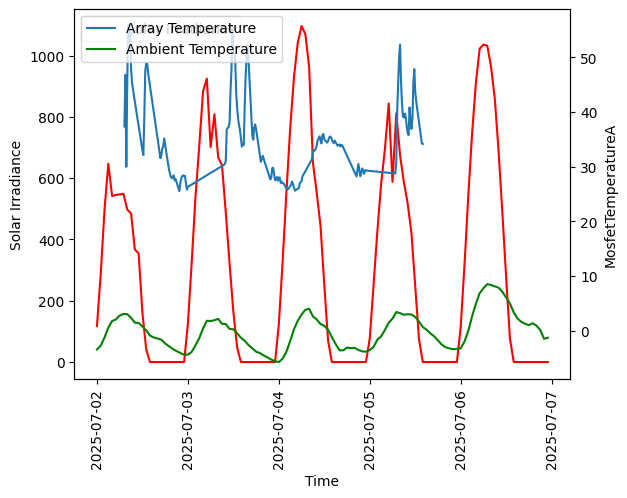

In [74]:
#this graph shows solar irradiance, array temperature, and ambient temperature over July 2-6 (FSGP 2025)

fig, ax1 = plt.subplots()
ax_twin = ax1.twinx()

plt.plot(df_15m.index, df_15m, label = "Array Temperature")
plt.plot(hourly_data['date'],hourly_data['temperature_2m'], color = 'green', label = "Ambient Temperature")

ax1.plot(hourly_data['date'],hourly_data['shortwave_radiation_instant'], color = "red", label = "Solar Irradiance")

ax1.set_xlabel("Time")
ax1.set_ylabel("Solar Irradiance")
ax_twin.set_ylabel("MosfetTemperatureA")

ax1.tick_params("x", rotation  = 90)
#ax1.set_xticks(minutely_15.timeformat)

plt.legend(loc = "upper left")
ax1.legend(loc = "upper left")
plt.show()

import the Physics Array Temperature Model for validation/sanity checks


In [76]:
from v4.array_temperature.arrayTemperatureModel import arrayTemperatureModel
def model(u0, u1):
    return arrayTemperatureModel(hourly_data['temperature_2m'], hourly_data['shortwave_radiation_instant'], 0, u0, u1)

model = model(22, 0.8)
print(model.calculateArrayTemperature())


[ 1.8935347e+00  1.0364137e+01  2.1387180e+01  2.9999233e+01
  2.6391014e+01  2.6875341e+01  2.7645386e+01  2.8025963e+01
  2.5642160e+01  2.4427845e+01  1.8177454e+01  1.7554525e+01
  8.0708389e+00  1.9637234e+00 -8.7300003e-01 -1.2230000e+00
 -1.4230000e+00 -1.6230000e+00 -2.3230000e+00 -2.8230000e+00
 -3.3230000e+00 -3.7229998e+00 -4.0730000e+00 -4.3730001e+00
  1.2934799e+00  1.0832609e+01  2.1798904e+01  3.0714010e+01
  4.0591778e+01  4.3875725e+01  3.3674473e+01  3.8677563e+01
  3.2507423e+01  3.0509079e+01  2.3399044e+01  1.4952563e+01
  7.7067099e+00  1.6932418e+00 -1.2730000e+00 -1.8230001e+00
 -2.6229999e+00 -3.2229998e+00 -3.8229997e+00 -4.0730000e+00
 -4.5230002e+00 -4.8730001e+00 -5.2730002e+00 -5.5730000e+00
 -1.0213566e-01  9.7276592e+00  2.1370445e+01  3.2780659e+01
  4.2558723e+01  4.9203346e+01  5.2815674e+01  5.2470692e+01
  4.7815193e+01  3.2199566e+01  2.7188547e+01  2.1431530e+01
  1.2343058e+01  3.3490453e+00 -1.1730000e+00 -2.4229999e+00
 -3.5730000e+00 -3.57300

In [77]:
faiman_temp = model.calculateArrayTemperature()

In [78]:
import numpy as np
np.array(faiman_temp)

array([ 1.8935347e+00,  1.0364137e+01,  2.1387180e+01,  2.9999233e+01,
        2.6391014e+01,  2.6875341e+01,  2.7645386e+01,  2.8025963e+01,
        2.5642160e+01,  2.4427845e+01,  1.8177454e+01,  1.7554525e+01,
        8.0708389e+00,  1.9637234e+00, -8.7300003e-01, -1.2230000e+00,
       -1.4230000e+00, -1.6230000e+00, -2.3230000e+00, -2.8230000e+00,
       -3.3230000e+00, -3.7229998e+00, -4.0730000e+00, -4.3730001e+00,
        1.2934799e+00,  1.0832609e+01,  2.1798904e+01,  3.0714010e+01,
        4.0591778e+01,  4.3875725e+01,  3.3674473e+01,  3.8677563e+01,
        3.2507423e+01,  3.0509079e+01,  2.3399044e+01,  1.4952563e+01,
        7.7067099e+00,  1.6932418e+00, -1.2730000e+00, -1.8230001e+00,
       -2.6229999e+00, -3.2229998e+00, -3.8229997e+00, -4.0730000e+00,
       -4.5230002e+00, -4.8730001e+00, -5.2730002e+00, -5.5730000e+00,
       -1.0213566e-01,  9.7276592e+00,  2.1370445e+01,  3.2780659e+01,
        4.2558723e+01,  4.9203346e+01,  5.2815674e+01,  5.2470692e+01,
      

In [87]:
len(faiman_temp)

120

In [90]:
df_15m.head()

,value
2025-07-02 07:15:00+00:00,37.371079
2025-07-02 07:30:00+00:00,46.801625
2025-07-02 07:45:00+00:00,29.980004
2025-07-02 08:00:00+00:00,45.573409
2025-07-02 08:15:00+00:00,55.745558


In [89]:
df_15m.tail()

,value
2025-07-05 13:00:00+00:00,38.086209
2025-07-05 13:15:00+00:00,36.774658
2025-07-05 13:30:00+00:00,35.463106
2025-07-05 13:45:00+00:00,34.271664
2025-07-05 14:00:00+00:00,34.174615


In [86]:
df_15m['faiman'] = faiman_temp

ValueError: Length of values (120) does not match length of index (316)

ValueError: x and y must have same first dimension, but have shapes (316,) and (120,)

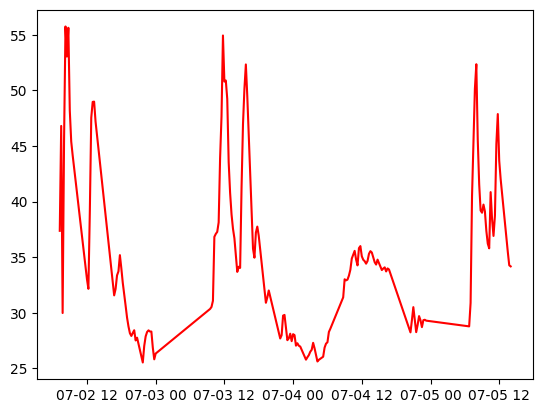

In [85]:
plt.plot(df_15m.index, df_15m, color = 'red')
plt.plot(df_15m.index, faiman_temp)
plt.xticks(rotation = 90)


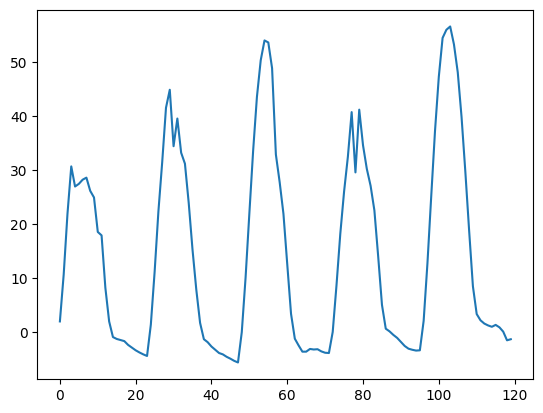

In [ ]:
#